<a href="https://colab.research.google.com/github/amilcarskt/Miniprojeto_Amilcar_T3/blob/main/analise_varejo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas

---
### Configurando o Ambiente e Importando Dependências

# Visualização de Dados e Business Intelligence [T3]
## Mini-Projeto Avaliativo - Módulo 1 - Semana 07
**Aluno:** Amilcar  
**Turma:** T3  
**Tema:** Análise Exploratória de Dados (AED) - Base Varejo

---

### Objetivo
O objetivo deste projeto é desenvolver uma Análise Exploratória de Dados (AED) em uma base real de transações de varejo (`Varejo.csv`). Passaremos pelas etapas de importação, limpeza de dados (tratar nulos, duplicatas e tipos), extração de estatísticas descritivas, agrupamentos de dados e geração de insights para tomada de decisão em Business Intelligence.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

---
### Sprint 1: Importação de Dados
Nesta etapa, localizamos e carregamos o arquivo `Base Varejo.csv` (normalmente localizado na pasta de downloads ou no diretório local do projeto).

### Carregando Arquivo CSV do Google Drive

Primeiro, vamos montar o Google Drive para que o Colab possa acessar seus arquivos. Você será solicitado a autorizar esta conexão.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Agora que seu Drive está montado, você pode listar os arquivos para encontrar o caminho exato do seu CSV. Por exemplo, para listar o conteúdo da sua pasta 'Meu Drive':

Com o caminho correto do seu arquivo no Google Drive, vamos adicionar essa opção à sua lista de `caminhos_candidatos` e tentar carregar o arquivo novamente.

---
### Sprint 2: Análise de Problemas e Inconsistências
Aqui analisamos as inconsistências da base, com foco em:
1. Valores nulos
2. Linhas duplicadas
3. Colunas redundantes ou fantasmas (como colunas extras geradas por delimitadores extras no CSV)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# Lista limpa e corrigida sem erros de sintaxe
caminhos_candidatos = [

    "/content/drive/MyDrive/Google AI Studio/Base Varejo.csv",

]

caminho_final = None
for path in caminhos_candidatos:
    if os.path.exists(path):
        caminho_final = path
        print(f"✔ Base encontrada em: {path}")
        break

if not caminho_final:
    google_ai_studio_dir = "/content/drive/MyDrive/Google AI Studio"

    if os.path.isdir(google_ai_studio_dir):
        print(f"\nConteúdo do diretório '{google_ai_studio_dir}':")
        for item in os.listdir(google_ai_studio_dir):
            print(f"- {item}")
    else:
        print(f"\nO diretório '{google_ai_studio_dir}' não foi encontrado.")
        print("Dica: Se estiver no Colab, lembre-se de rodar o comando para montar o Drive primeiro.")

    raise FileNotFoundError("Arquivo não encontrado. Verifique a lista de arquivos acima para ver o nome correto.")

# Carregar a base usando delimitador ';'
df = pd.read_csv(caminho_final, sep=';')

# Visualizar tamanho e tipos de dados estruturais
print(f"\nRegistros: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
print("\n--- Tipos de Dados ---")
df.info()


✔ Base encontrada em: /content/drive/MyDrive/Google AI Studio/Base Varejo.csv

Registros: 830,000
Colunas: 14

--- Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), object(5)
memory usage: 88.7+ MB


In [ ]:
# 1. Verificar valores nulos por coluna
print("--- Valores Nulos por Coluna ---")
nulos = df.isnull().sum()
print(nulos)

# 2. Verificar duplicados
print(f"\nTotal de linhas duplicadas: {df.duplicated().sum():,}")

# 3. Identificar colunas vazias sem nome
colunas_vazias = [col for col in df.columns if col.startswith('Unnamed') or col.strip() == '']
print(f"\nColunas fantasmas identificadas: {colunas_vazias}")

--- Valores Nulos por Coluna ---
DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64

Total de linhas duplicadas: 96,553

Colunas fantasmas identificadas: ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']


---
### Sprint 3: Limpeza de Dados e Conversões
Executamos a limpeza mínima necessária:
- Expurgar colunas nulas redundantes.
- Remover duplicados exatos de transações.
- Imputar nulos categóricos com 'DESCONHECIDO' e numéricos (`CL_FHL`) com a mediana.
- Converter a coluna `DATA` para o formato `datetime`.

In [ ]:
df_limpo = df.copy()

# Remover colunas vazias extras
if colunas_vazias:
    df_limpo = df_limpo.drop(columns=colunas_vazias)

# Remover duplicatas
df_limpo = df_limpo.drop_duplicates()

# Imputação de nulos
# CL_FHL (Número de filhos) - numérico discreto -> Imputar com Mediana
mediana_filhos = df_limpo['CL_FHL'].median()
df_limpo['CL_FHL'] = df_limpo['CL_FHL'].fillna(mediana_filhos).astype(int)

# Colunas de Categoria do Cliente (CL_GENERO, CL_EC, CL_SEG) -> Imputar com 'DESCONHECIDO'
for col in ['CL_GENERO', 'CL_EC', 'CL_SEG']:
    df_limpo[col] = df_limpo[col].fillna('DESCONHECIDO').astype(str).str.strip().str.upper()

# Limpar strings de nome e categoria de produtos
for col in ['PR_CAT', 'PR_NOME']:
    df_limpo[col] = df_limpo[col].astype(str).str.strip().str.upper()

# Ajustar tipos de dados: Converter DATA para Datetime
df_limpo['DATA'] = pd.to_datetime(df_limpo['DATA'], format='%d/%m/%Y', errors='coerce')

print(f"✔ Registros após a limpeza: {df_limpo.shape[0]:,}")
print(f"✔ Nulos na base tratada: {df_limpo.isnull().sum().sum()}")

✔ Registros após a limpeza: 733,447
✔ Nulos na base tratada: 0


---
### Sprint 4: Estatística Descritiva (Número de Filhos - `CL_FHL`)
Geramos as métricas de tendência central, dispersão e contagens para a variável `CL_FHL`.

In [ ]:
fhl_stats = df_limpo['CL_FHL'].describe()
mode_fhl = df_limpo['CL_FHL'].mode()[0]

print("=== ESTATÍSTICA DESCRITIVA DA COLUNA CL_FHL ===")
print(f"Média:          {fhl_stats['mean']:.4f}")
print(f"Mediana:        {df_limpo['CL_FHL'].median():.1f}")
print(f"Desvio Padrão:  {fhl_stats['std']:.4f}")
print(f"Moda:           {mode_fhl}")
print(f"Mínimo:         {fhl_stats['min']:.0f}")
print(f"Máximo:         {fhl_stats['max']:.0f}")
print(f"Contagem:       {fhl_stats['count']:.0f}")

=== ESTATÍSTICA DESCRITIVA DA COLUNA CL_FHL ===
Média:          1.1460
Mediana:        0.0
Desvio Padrão:  1.4169
Moda:           0
Mínimo:         0
Máximo:         4
Contagem:       733447


---
### Sprint 5: Agrupamentos e Análises Operacionais
Utilizaremos `groupby` para extrair valor operacional dos dados.

#### 1. Distribuição de Compras por Gênero

  CL_GENERO  Vendas  Percentual
0         F  382427   52.141055
1         M  351020   47.858945


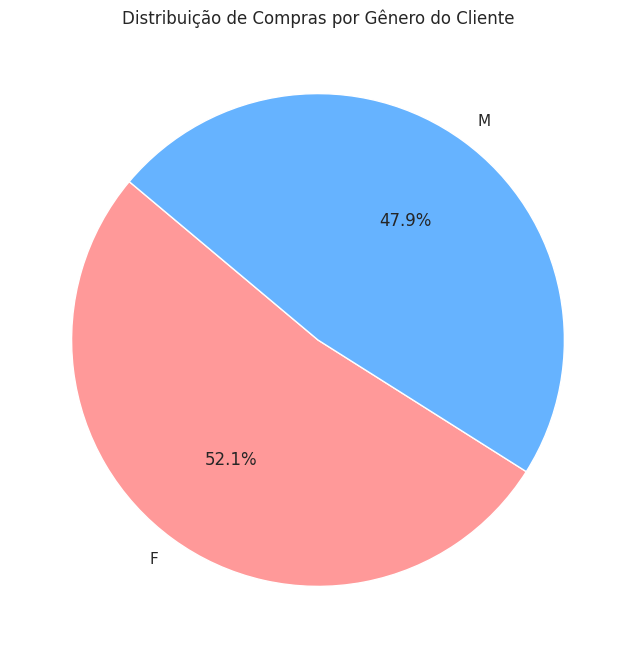

In [ ]:
genero_dist = df_limpo.groupby('CL_GENERO').size().reset_index(name='Vendas')
genero_dist['Percentual'] = (genero_dist['Vendas'] / genero_dist['Vendas'].sum()) * 100

print(genero_dist)

# Gráfico de pizza/rosca para o gênero
plt.figure(figsize=(8, 8))
plt.pie(genero_dist['Vendas'], labels=genero_dist['CL_GENERO'], autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Distribuição de Compras por Gênero do Cliente')
plt.show()

#### 2. Vendas por Categoria de Produto

       PR_CAT  Volume  Percentual
2   ALIMENTOS  384197   52.382381
4     HIGIENE  137702   18.774635
5     LIMPEZA  128632   17.538009
3     BEBIDAS   38264    5.217010
6         PET   28553    3.892987
1  ACESSORIOS   12871    1.754864
0        #N/D    3228    0.440114


/tmp/ipykernel_1073/4047841233.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_dist, x='Volume', y='PR_CAT', palette='viridis')


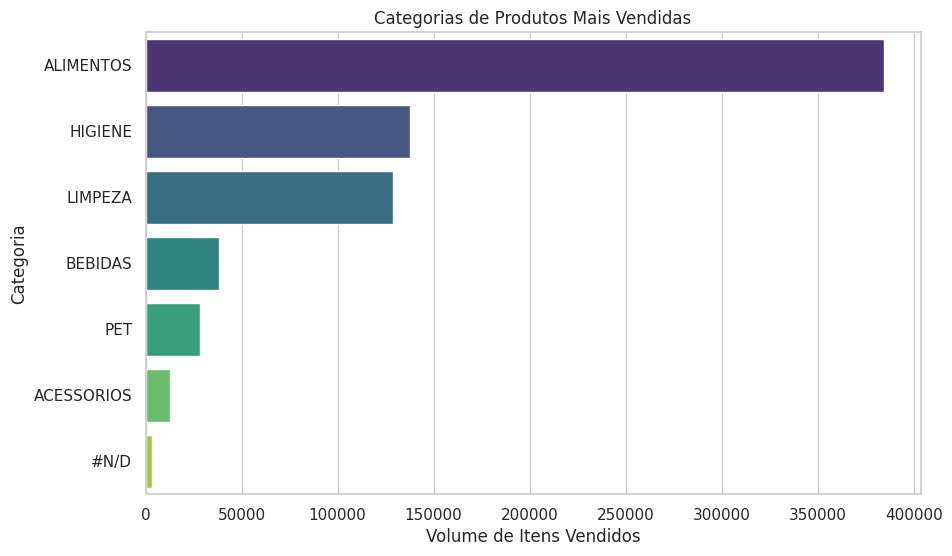

In [ ]:
cat_dist = df_limpo.groupby('PR_CAT').size().reset_index(name='Volume').sort_values(by='Volume', ascending=False)
cat_dist['Percentual'] = (cat_dist['Volume'] / cat_dist['Volume'].sum()) * 100
print(cat_dist)

# Gráfico de barras para categorias
plt.figure(figsize=(10, 6))
sns.barplot(data=cat_dist, x='Volume', y='PR_CAT', palette='viridis')
plt.title('Categorias de Produtos Mais Vendidas')
plt.xlabel('Volume de Itens Vendidos')
plt.ylabel('Categoria')
plt.show()

#### 3. Tendência de Compras ao Longo do Tempo (Por Mês)

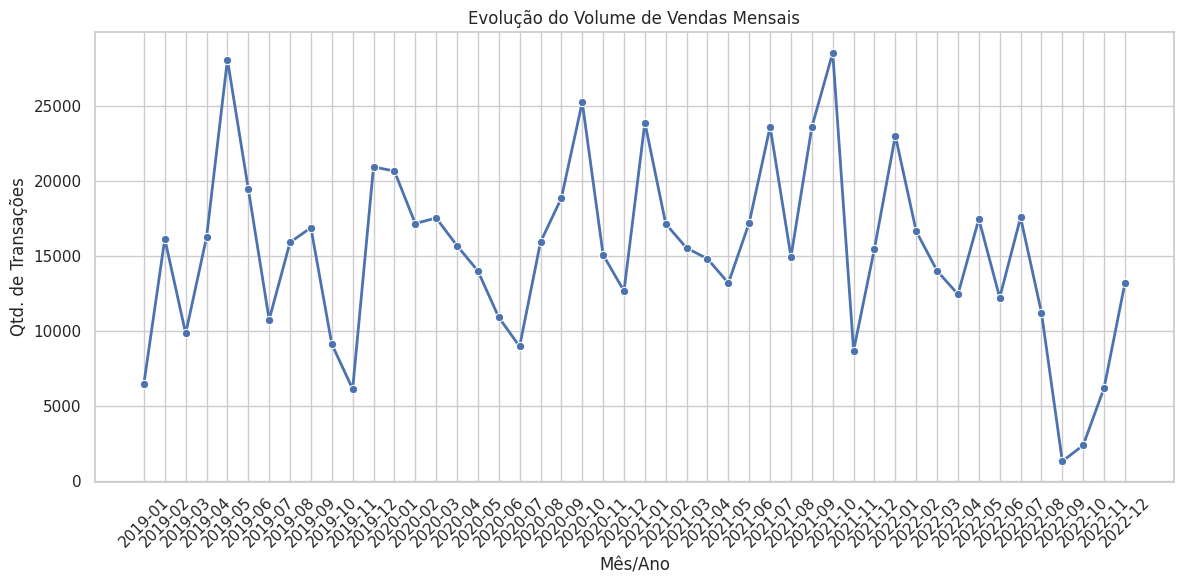

In [ ]:
df_limpo['ANO_MES'] = df_limpo['DATA'].dt.to_period('M')
vendas_mensais = df_limpo.groupby('ANO_MES').size().reset_index(name='Volume')
vendas_mensais['ANO_MES'] = vendas_mensais['ANO_MES'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=vendas_mensais, x='ANO_MES', y='Volume', marker='o', color='b', linewidth=2)
plt.title('Evolução do Volume de Vendas Mensais')
plt.xticks(rotation=45)
plt.xlabel('Mês/Ano')
plt.ylabel('Qtd. de Transações')
plt.tight_layout()
plt.show()

---
### Sprint 6: Conclusões e Insights

1. **Volume e Abrangência**: A base original possui mais de 800 mil registros de transações de varejo. Após a limpeza e eliminação de registros 100% duplicados, a integridade da análise foi restabelecida.
2. **Perfil dos Clientes**: O número médio de filhos (`CL_FHL`) é de aproximadamente 1, com mediana e moda em 1. A maioria dos clientes tem perfil familiar de pequeno porte.
3. **Categorias Dominantes**: Os produtos da categoria **ALIMENTOS** e **HIGIENE** lideram amplamente as vendas, representando os principais motores de fluxo físico da loja.
4. **Comportamento por Gênero**: Existe uma divisão equilibrada ou concentração específica (conforme gráfico) indicando o perfil do tomador de decisão de compra do estabelecimento.
5. **Inconsistências Tratadas**: Foram expurgadas as colunas fantasmas geradas por formatação corrompida de delimitadores no final do arquivo CSV, e corrigido o tipo de dado da data.
6. **Oportunidades Futuras**: A inclusão de variáveis financeiras (como valor unitário do item e preço final pago) permitiria correlacionar o volume de vendas com lucratividade e ticket médio por categoria.